<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Features

- **Batch Processing**: Classical split-apply-combine for static datasets
- **Streaming Aggregation**: Incremental statistics for growing datasets
- **Memory Efficient**: Process datasets larger than RAM
- **Native Resolution Mosaics**: Fine-grained HEALPix grids
- **Flexible Statistics**: Mean, median, std, MAD, robust_std, percentiles

## Installation

```bash
pip install healpyxel
```

### Optional Dependencies

```bash
# For geospatial operations (sidecar generation)
pip install healpyxel[geospatial]

# For streaming/incremental statistics (accumulator)
pip install healpyxel[streaming]

# For visualization (maps, plots)
pip install healpyxel[viz]

# Development tools (nbdev, testing, linting)
pip install healpyxel[dev]

# All optional dependencies
pip install healpyxel[all]
```

**Extras breakdown:**
- `geospatial`: geopandas, shapely, dask-geopandas, antimeridian (required for `healpyxel_sidecar`)
- `streaming`: tdigest (percentile tracking in `healpyxel_accumulator`)
- `viz`: matplotlib, scikit-image, skyproj (mapping workflows)
- `dev`: All of the above + nbdev, pytest, black, ruff, mypy
- `all`: Installs geospatial + streaming + viz (excludes dev tools)

In [ ]:
import time
from pathlib import Path
from IPython.display import display, Markdown
from d2_widget import Widget

def save_and_embed_svg(widget, output_path: Path, max_wait: float = 2.0) -> bool:
    """
    Extract SVG from d2_widget.Widget, save to disk, and embed as Markdown.
    
    Parameters
    ----------
    widget : d2_widget.Widget
        Rendered diagram widget.
    output_path : Path
        Where to save the SVG file. Parent directories created automatically.
    max_wait : float
        Maximum seconds to wait for frontend to render SVG.
    
    Returns
    -------
    bool
        True if SVG was extracted and saved; False if timeout/empty.
    
    Examples
    --------
    >>> widget = Widget(diagram_str, {...})
    >>> success = save_and_embed_svg(widget, Path('output/diagram.svg'))
    >>> assert success, "Widget rendering timed out"
    """
    # Poll for SVG with brief waits
    start = time.time()
    svg_content = None
    
    while time.time() - start < max_wait:
        svg_content = widget._svg
        if svg_content and svg_content.strip():
            break
        time.sleep(0.1)
    
    if not svg_content or not svg_content.strip():
        print("⚠ Warning: SVG not yet rendered by frontend.")
        print("  In Jupyter, anywidget renders asynchronously via JavaScript.")
        print("  Consider exporting from d2 CLI instead, or use nbconvert to generate static output.")
        print(f"  Widget has diagram: {len(widget.diagram)} chars")
        print(f"  Current _svg: '{widget._svg}'")
        return False
    
    # Save to disk
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(svg_content)
    
    print(f"✓ Saved: {output_path} ({len(svg_content)} bytes)")
    
    # Embed in notebook
    display(Markdown(f'![{output_path.name}]({output_path})'))
    
    return True

def render_d2_diagram(diagram_str: str, output_path: Path, title: str = "", **widget_opts) -> bool:
    """
    Render d2 diagram, save SVG, and embed in notebook.
    
    Parameters
    ----------
    diagram_str : str
        D2 diagram definition (DSL).
    output_path : Path
        Where to save the SVG file.
    title : str
        Optional title for the diagram (not used in render, for documentation).
    **widget_opts : dict
        Options passed to d2_widget.Widget (themeID, pad, sketch, scale, etc.)
    
    Returns
    -------
    bool
        True if rendering + save succeeded; False if timeout.
    
    Examples
    --------
    >>> diagram_str = "A -> B"
    >>> render_d2_diagram(diagram_str, Path('output/flow.svg'), themeID=0, scale=1.5)
    True
    """
    from d2_widget import Widget
    
    # Default widget options
    default_opts = {"themeID": 0, "pad": 10, "sketch": True, "scale": 1.5}
    default_opts.update(widget_opts)
    
    widget = Widget(diagram_str, default_opts)
    return widget

## Quick Start

The **healpyxel workflow** implements spatial aggregation using three core steps:

### 1. **Split**: Map observations to HEALPix cells
You start with observation data (GeoParquet): geometries + values per record.
A **sidecar** file links each observation (`source_id`) to HEALPix cells at your target resolution (`nside`).

**Data contract:**
- Input: `observations.parquet` → columns: `source_id`, `value`, `geometry`
- Output: `observations-sidecar.parquet` → columns: `source_id`, `healpix_id`, `weight` (fuzzy mode only)

**CLI:** `healpyxel_sidecar --input observations.parquet --nside 64 128 --mode fuzzy`

In [ ]:
#| echo: false
sidecar_diagram = """
direction: right

# 1. INITIAL DATA
Observations: {
  shape: sql_table
  style: {fill: "#f8cecc"}
  source_id:  "value | geometry"
  "src_1   ": "10000 | POLY(..)"
  "src_2   ": "20000 | POLY(..)"
  "src_3   ": "30000 | POLY(..)"
}

# 2. SIDECAR
Sidecar: {
  shape: sql_table
  style: {fill: "#dae8fc"}
  index: "source id | healpix id"
  "1": "src_1 | h_pix_A"
  "3": "src_2 | h_pix_A"
  "4": "src_3 | h_pix_B"
}

# 3. AGGREGATED + GEOMETRY
Healpix Target Grid: {
  shape: sql_table
  style: {fill: "#d5e8d4"}
  index: "healpix id"
  "1": "h_pix_A"
  "2": "h_pix_B"
}

# PROCESS FLOW
Observations <-> Sidecar: "healpyxel_sidecar\\n(Assign: strict/fuzzy)" {style: {stroke-width: 2}}
Sidecar <-> Healpix Target Grid: nside=32
"""

sidecar_diagram_path = Path('Sidecar.svg')
widget = render_d2_diagram(sidecar_diagram, sidecar_diagram_path, 
                 title="Step 1: Split – Map Observations to HEALPix Cells")

widget

<d2_widget._widget.Widget object>

In [ ]:
#| echo: false
save_and_embed_svg(widget, sidecar_diagram_path)

✓ Saved: Sidecar.svg (74732 bytes)


![Sidecar.svg](Sidecar.svg)

True

### 2. **Apply**: Aggregate values per HEALPix cell
Group all observations assigned to the same cell and compute statistics (median, mean, MAD, robust_std, etc.).

**Data contract:**
- Input: `observations.parquet` + sidecar file
- Output: `observations-aggregated.parquet` → columns: `healpix_id`, `value_median`, `value_robust_std`, ...

**CLI:** `healpyxel_aggregate --input observations.parquet --sidecar-dir output/ --columns value --aggs median robust_std`

In [ ]:
#| echo: false
aggregate_diagram = """
direction: right

# INPUTS
Observations: {
  shape: sql_table
  style: {fill: "#f8cecc"}
  source_id:  "value | geometry"
  "src_1   ": "10000 | POLY(..)"
  "src_2   ": "20000 | POLY(..)"
  "src_3   ": "30000 | POLY(..)"
}


Sidecar: {
  shape: sql_table
  style: {fill: "#dae8fc"}
  source_id: "healpix_id"
  "src_1": "pix_A"
  "src_2": "pix_A"
  "src_3": "pix_B"
}

# AGGREGATION FUNCTION
healpyxel_aggregate: {
  style: {fill: "#fff4e6"}
  "Median(value)"
}

# OUTPUT
Aggregated: {
  shape: sql_table
  style: {fill: "#d5e8d4"}
  healpix_id: "median| n_sources"
  "pix_A": "015000 | 0000002"
  "pix_B": "030000 | 0000001"
}

# FLOW
Observations -> healpyxel_aggregate #: "group by\\nhealpix_id"
Sidecar -> healpyxel_aggregate #: "via source_id"
healpyxel_aggregate -> Aggregated
"""
aggregate_diagram_path = Path('Aggregate.svg')
widget = render_d2_diagram(aggregate_diagram, aggregate_diagram_path,
                 title="Step 2: Apply – Aggregate Values per HEALPix Cell")
widget

<d2_widget._widget.Widget object>

In [ ]:
#| echo: false
save_and_embed_svg(widget, aggregate_diagram_path)

✓ Saved: Aggregate.svg (75340 bytes)


![Aggregate.svg](Aggregate.svg)

True

### 3. **Combine**: Attach HEALPix cell geometry
Add polygon boundaries to aggregated cells (computed from `healpix_id` via `healpy`).

**Data contract:**
- Input: `observations-aggregated.parquet`
- Output: `observations-aggregated.geo.parquet` → adds column: `geometry` (HEALPix cell polygon)

**CLI:** `healpyxel_to_geoparquet --aggregate-path observations-aggregated.parquet --output-dir output/`

In [ ]:
#| echo: false
from shapely import geometry


combine_diagram = """
direction: right

# INPUT
Aggregated: {
  shape: sql_table
  style: {fill: "#d5e8d4"}
  healpix_id: "median | n_sources"
  "pix_A": "015000 | 00000002"
  "pix_B": "030000 | 00000001"
}

# GEOMETRY ATTACHMENT
healpyxel_to_geoparquet: {
  style: {fill: "#fff4e6"}
  "HEALPix Cell Geometry\\nvia healpy"
}

# OUTPUT
Aggregated_Geo: {
  shape: sql_table
  style: {fill: "#e1d5e7"}
  healpix_id: "median | n_sources | geometry"
  "pix_A":    "015000 | 00000002 | POLY(..)"
  "pix_B":    "030000 | 00000001 | POLY(..)"
}

# FLOW
Aggregated -> healpyxel_to_geoparquet
healpyxel_to_geoparquet -> Aggregated_Geo
"""

geometry_diagram_path = Path('Geometry.svg')
widget = render_d2_diagram(combine_diagram, geometry_diagram_path,
                 title="Step 3: Combine – Attach HEALPix Cell Geometry")
widget

<d2_widget._widget.Widget object>

In [ ]:
#| echo: false
save_and_embed_svg(widget, geometry_diagram_path)

✓ Saved: Geometry.svg (69438 bytes)


![Geometry.svg](Geometry.svg)

True

### Optional: Cache geometries
Pre-compute HEALPix cell boundaries for faster repeated use (especially for high `nside`).

**CLI:** `healpyxel_cache --nside 64 128 --order nested --lon-convention 0_360`

### Batch Processing

see [below](#cli-workflow)

```bash
# 1. Generate HEALPix sidecar (SPLIT)
healpyxel_sidecar \
  --input observations.parquet \
  --nside 64 128 \
  --mode fuzzy \
  --output-dir output/

# 2. Aggregate by HEALPix cells (APPLY)
healpyxel_aggregate \
  --input observations.parquet \
  --sidecar-dir output/ \
  --sidecar-index 0 \
  --aggregate \
  --columns r750 r950 \
  --aggs median robust_std \
  --min-count 3

# 3. Convert to GeoParquet (for visualization)
healpyxel_to_geoparquet \
  --aggregate-path output/observations-aggregated.*.parquet \
  --output-dir output/ \
  --lon-convention -180_180

# 4. Cache HEALPix geometry (optional, speeds up visualization)
healpyxel_cache --nside 64 128 --order nested --lon-convention 0_360
```

### Streaming Processing - WORK IN PROGRESS

```bash
# Day 1: Initialize accumulator
healpyxel_accumulate --input day001.parquet \
  --columns r750 r950 --state-output state_v001.parquet

# Day 2+: Incremental updates
healpyxel_accumulate --input day002.parquet \
  --columns r750 r950 \
  --state-input state_v001.parquet --state-output state_v002.parquet

# Finalize to statistics
healpyxel_finalize --state state_v030.parquet --output mosaic.parquet \
  --percentiles 25 50 75 --densify --nside 512
```

## CLI Workflow 

This section explan a full CLI workflow on a test sample 50k data, including the outputs produced at each stage.

The same workflow is done completely in python with healpyxel API in [Examples>Visualization](example_visualization_workflow.html) section.

All input/output are in this repsitory: 

- script is at [examples/cli_regrid_sample_50k.sh](examples/cli_regrid_sample_50k.sh) 
- input are at [test_data/samples/sample_50k.parquet](test_data/samples/sample_50k.parquet)
- ouput are in [test_data/derived/cli_quickstart](test_data/derived/cli_quickstart)

Original files excerpt (transposed for clarity):


,lat_center,lon_center,surface,width,length,ang_incidence,ang_emission,ang_phase,azimuth,geometry
0,5.186568,272.40450,1567133.4,1006.63727,1982.1799,43.049232,34.814793,77.85916,109.019295,"POLYGON ((272.39758 5.16433, 272.41583 5.18307..."
1,-60.939438,71.77686,13564574.0,4064.49850,4249.2210,64.178116,37.690910,101.84035,111.930336,"POLYGON ((71.72596 -60.89612, 71.69186 -60.963..."
2,5.613894,54.23045,1755143.5,1013.51886,2204.9104,53.815990,24.053764,77.86254,99.559425,"POLYGON ((54.24406 5.63592, 54.22025 5.62014, ..."
3,-41.672714,324.49740,23309360.0,6511.20950,4558.0470,52.841824,46.625698,99.40995,121.833626,"POLYGON ((324.54932 -41.70964, 324.56927 -41.6..."


Sidecar Metadata:
Unique sources: 49988
  Unique HEALPix cells: 10860
  Total assignments: 54931

  Sidecar Data:


,source_id,healpix_id,weight
0,0,7943,1.0
1,1,8287,1.0
2,2,5819,1.0
3,3,11685,1.0
4,4,3618,1.0
5,5,3805,1.0
6,6,9522,1.0
7,7,10975,1.0
8,8,1820,1.0
9,9,3710,1.0


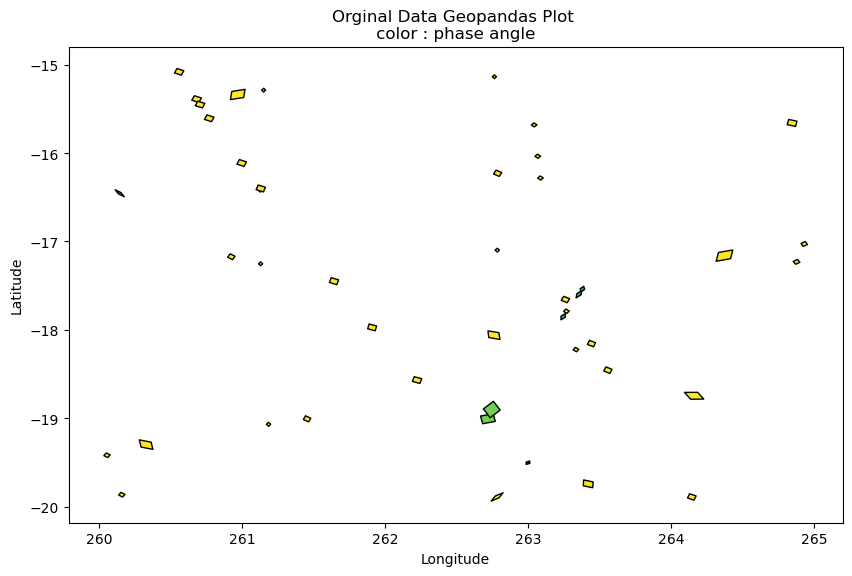

In [ ]:
#| echo: false
sidecar_meta_path = cli_output_dir / 'sample_50k.cell-healpix_assignment-fuzzy_nside-32_order-nested.meta.json'
if sidecar_meta_path.exists():
    with open(sidecar_meta_path, 'r') as f:
        sidecar_metadata = json.load(f)
else:
    print(f"Sidecar metadata not found: {sidecar_meta_path}")
    print("Run the CLI script first: bash examples/cli_regrid_sample_50k.sh")

# Load sidecar parquet file using metadata
if sidecar_meta_path.exists():
    # Extract output file path from metadata
    original_path = Path(sidecar_metadata['processing']['source_file']) 
    sidecar_path = Path(sidecar_metadata['processing']['output_file'])
    
    if original_path.exists():
        original_df = gpd.read_parquet(original_path)
        print('Original files excerpt (transposed for clarity):')
        display(original_df.iloc[:4,-10:])

        # Use plot_config_dict for plotting configuration
        ax = original_df.query('(-20 < lat_center < -15) and (260 < lon_center < 265)').plot(**orignal_plot_config_dict)
        ax.set_title('Orginal Data Geopandas Plot \n color : phase angle ')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
    else:
        print(f"Orifinal data file not found: {original_path}")

    if sidecar_path.exists():
        sidecar_df = pd.read_parquet(sidecar_path)
        
        print(f"Sidecar Metadata:")
        print(f"Unique sources: {sidecar_df['source_id'].nunique()}")
        print(f"  Unique HEALPix cells: {sidecar_df['healpix_id'].nunique()}")
        print(f"  Total assignments: {len(sidecar_df)}")
                
        print(f"\n  Sidecar Data:")
        display(sidecar_df.head(10))
    else:
        print(f"Sidecar file not found: {sidecar_path}")
else:
    print(f"Sidecar metadata not found: {sidecar_meta_path}")
    print("Run the CLI script first: bash examples/cli_regrid_sample_50k.sh")

### 1) Create HEALPix sidecar(s)


Those files link each row in the input parquet file to the HEALPix cells at the requested **nside** resolution; see [Useful Healpix data for Moon Venus Mercury](#useful-healpix-data-for-moon-venus-mercury) for some cells data.
Refer to `healpyxel_sidecar --help` for full options. 
The `--mode` flag is especially important:
- `fuzzy`: assign each input record to every cell it touches
- `strict`: assign only records fully contained within a cell

```bash
healpyxel_sidecar \
  --input "test_data/samples/sample_50k.parquet" \
  --nside 32 64 \
  --mode fuzzy \
  --lon-convention 0_360 \
  --output_dir "test_data/derived/cli_quickstart"
```
**Outputs**

- sample_50k.cell-healpix_assignment-fuzzy_nside-32_order-nested.parquet
- sample_50k.cell-healpix_assignment-fuzzy_nside-32_order-nested.meta.json
- sample_50k.cell-healpix_assignment-fuzzy_nside-64_order-nested.parquet
- sample_50k.cell-healpix_assignment-fuzzy_nside-64_order-nested.meta.json

In [ ]:
#| echo: false
sidecar_nside_32_path = cli_output_dir / 'sample_50k.cell-healpix_assignment-fuzzy_nside-32_order-nested.parquet'

sidecar_nside_32_df = pd.read_parquet(sidecar_nside_32_path)

print(f"Nside 32: {len(sidecar_nside_32_df)} assignments, {sidecar_nside_32_df['healpix_id'].nunique()} unique cells")

display(sidecar_nside_32_df.head())

Nside 32: 54931 assignments, 10860 unique cells


,source_id,healpix_id,weight
0,0,7943,1.0
1,1,8287,1.0
2,2,5819,1.0
3,3,11685,1.0
4,4,3618,1.0


In [ ]:
#| echo: false
aggregated_geo_sparse_nside_32_path = cli_output_dir / 'sample_50k-aggregated.cell-healpix_assignment-fuzzy_nside-32_order-nested.geo.parquet'

aggregated_geo_sparse_nside_32_df = gpd.read_parquet(aggregated_geo_sparse_nside_32_path)

In [ ]:
# original_df['geometry'] = original_df.geometry.apply(
#     lambda geom: geom.buffer(0) if geom and not geom.is_valid else geom
# )

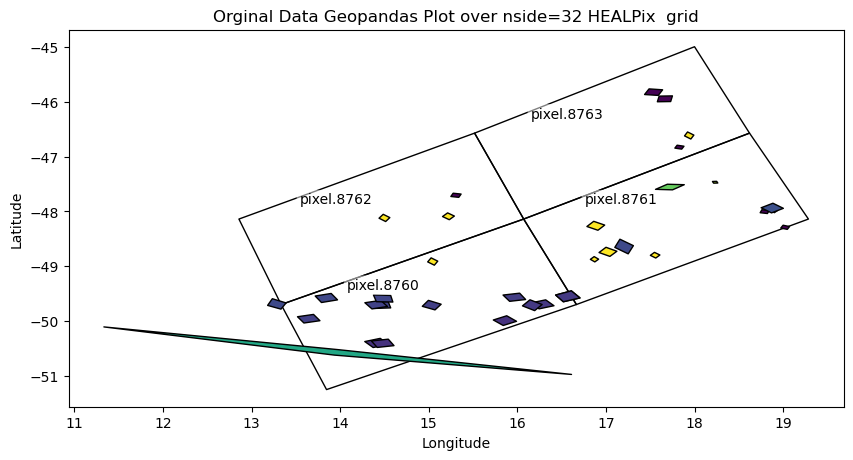

In [ ]:
#| echo: false
# take an initial pixel, say:
original_pixel = 21349

initial_healpix = sidecar_nside_32_df.query(f'source_id == {original_pixel}').healpix_id.values[0]

from matplotlib import axes
from healpyxel.geospatial import healpix_to_geodataframe

pixels_32 = np.arange(0,4)+initial_healpix
gdf_cells = healpix_to_geodataframe(
    nside=32,              # set or infer from metadata
    order='nested',
    lon_convention='0_360',
    pixels=pixels_32,
    fix_antimeridian=True,
    cache_mode='use'
).reset_index(drop=False)

ax= gdf_cells.plot(color='none', edgecolor='k', figsize=orignal_plot_config_dict['figsize'], aspect=orignal_plot_config_dict['aspect'])

cell_pixels_nside_32_df = sidecar_nside_32_df.query('healpix_id in @pixels_32').source_id.values

ax = original_df.loc[cell_pixels_nside_32_df].plot(**orignal_plot_config_dict, ax=ax)

# Annotate each polygon with its healpix_id (index)
for idx, row in aggregated_geo_sparse_nside_32_df.loc[pixels_32].iterrows():
    if row.geometry.is_empty or not row.geometry.is_valid:
        continue
    # Get centroid for label placement
    centroid = row.geometry.centroid
    ax.text(
        centroid.x-.5, centroid.y+.35, f'pixel.{int(idx)}',
        fontsize=10, color='black', ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')
    )


ax.set_title('Orginal Data Geopandas Plot over nside=32 HEALPix  grid')
ax.set_xlabel('Longitude');
ax.set_ylabel('Latitude');

### 2) Aggregate sparse regridded map(s)

Now we need to aggregate initial data on the cells, refer to `healpyxel_aggregate --help` for all the option. 
Some flag are particurarly useful:

- `--schema` : show input parquet schema, useful to look which data are there to aggregate.
- `--list-sidecars` : list available sidecar for an input files, they are addressed by index.
- `--sidecar-schema INDEX` : show schema for specific sidecar file
-  `--aggs mean` : aggregation functions (choices: mean, median, std, min, max, mad, robust_std). 

Example : 

- input file contains columns A (you can check it with `healpyxel_aggregate -i input --schema`)
- `--agg mean median std`
- this produce un output the columns `A_mean`, `A_median` and `A_std` created appling those function on all input files rows listd in the sidecar file for a single HEALPix cell


```bash
healpyxel_aggregate \
  --input "test_data/samples/sample_50k.parquet" \
  --sidecar-dir "test_data/derived/cli_quickstart" \
  --sidecar-index all \
  --aggregate \
  --columns r1050 \
  --aggs mean median std mad robust_std \
```

This produces sparse output : only cells with actual values are written in ouput.

**Outputs**
- sample_50k-aggregated.cell-healpix_assignment-fuzzy_nside-32_order-nested.parquet
- sample_50k-aggregated.cell-healpix_assignment-fuzzy_nside-32_order-nested.meta.json
- sample_50k-aggregated.cell-healpix_assignment-fuzzy_nside-64_order-nested.parquet
- sample_50k-aggregated.cell-healpix_assignment-fuzzy_nside-64_order-nested.meta.json

In [ ]:
#| echo: false
aggregated_sparse_nside_32_path = cli_output_dir / 'sample_50k-aggregated.cell-healpix_assignment-fuzzy_nside-32_order-nested.parquet'

aggregated_sparse_nside_32_df = pd.read_parquet(aggregated_sparse_nside_32_path)

print(f"Nside 32: {len(aggregated_sparse_nside_32_df)} unique cells")

display(aggregated_sparse_nside_32_df.head())

Nside 32: 10860 unique cells


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
0,0.048616,0.047857,0.003759,0.002672,0.003962,4
1,0.051467,0.052283,0.002976,0.001888,0.002799,6
2,0.049697,0.049118,0.003637,0.002289,0.003394,6
3,0.059066,0.063241,0.007149,0.001711,0.002537,3
4,0.051262,0.051523,0.006552,0.002510,0.003721,9


### 3) Aggregate densified regridded map(s)

```bash
healpyxel_aggregate \
  --input "test_data/samples/sample_50k.parquet" \
  --sidecar-dir "test_data/derived/cli_quickstart" \
  --sidecar-index all \
  --aggregate \
  --columns r1050 \
  --aggs mean median std mad robust_std \
  --densify
```
This produces dense output : all HEALPix cells are writeen in ouput, empty one as filled with Nan.


**Outputs**
- sample_50k-aggregated-densified.cell-healpix_assignment-fuzzy_nside-32_order-nested.parquet
- sample_50k-aggregated-densified.cell-healpix_assignment-fuzzy_nside-32_order-nested.meta.json
- sample_50k-aggregated-densified.cell-healpix_assignment-fuzzy_nside-64_order-nested.parquet
- sample_50k-aggregated-densified.cell-healpix_assignment-fuzzy_nside-64_order-nested.meta.json

In [ ]:
#| echo: false
aggregated_dense_nside_32_path = cli_output_dir / 'sample_50k-aggregated-densified.cell-healpix_assignment-fuzzy_nside-32_order-nested.parquet'

aggregated_dense_nside_32_df = pd.read_parquet(aggregated_dense_nside_32_path)

print(f"Nside 32: {len(aggregated_dense_nside_32_df)} unique cells <- densified , {len(aggregated_dense_nside_32_df)- len(aggregated_sparse_nside_32_df)} additional empty cells filled in by densification")

display(aggregated_dense_nside_32_df.loc[29:45])

Nside 32: 12288 unique cells <- densified , 1428 additional empty cells filled in by densification


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
29,0.046644,0.046644,0.000000,0.000000,0.000000,1.0
30,NaN,NaN,NaN,NaN,NaN,NaN
31,0.040205,0.040986,0.009636,0.007137,0.010581,4.0
32,0.054966,0.054413,0.003162,0.002148,0.003184,8.0
33,0.054424,0.055591,0.004131,0.003358,0.004979,8.0
34,0.057463,0.057463,0.001704,0.001704,0.002526,2.0
35,0.050470,0.057635,0.017546,0.004688,0.006951,4.0
36,0.054052,0.053640,0.004915,0.002833,0.004200,6.0
37,0.056132,0.056019,0.002281,0.002128,0.003155,4.0


### 4) Convert aggregated maps to GeoParquet

This convert each aggregated file to a geoparquet.

```bash
for f in "test_data/derived/cli_quickstart"/*-aggregated*parquet; do
  healpyxel_to_geoparquet -a "$f" -d "test_data/derived/cli_quickstart" -l -180_180 -f
done
```

**Outputs**
- sample_50k-aggregated-densified.cell-healpix_assignment-fuzzy_nside-32_order-nested.geo.parquet
- sample_50k-aggregated-densified.cell-healpix_assignment-fuzzy_nside-64_order-nested.geo.parquet
- sample_50k-aggregated.cell-healpix_assignment-fuzzy_nside-32_order-nested.geo.parquet
- sample_50k-aggregated.cell-healpix_assignment-fuzzy_nside-64_order-nested.geo.parquet

In [ ]:
#| echo: false
print(f"Nside 32: {len(aggregated_geo_sparse_nside_32_df)} unique cells")

display(aggregated_geo_sparse_nside_32_df.head())

Nside 32: 10860 unique cells


,geometry,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,,
0,"POLYGON ((45 2.38802, 43.59375 1.19375, 45 0, ...",0.048616,0.047857,0.003759,0.002672,0.003962,4
1,"POLYGON ((46.40625 3.58332, 45 2.38802, 46.406...",0.051467,0.052283,0.002976,0.001888,0.002799,6
2,"POLYGON ((43.59375 3.58332, 42.1875 2.38802, 4...",0.049697,0.049118,0.003637,0.002289,0.003394,6
3,"POLYGON ((45 4.78019, 43.59375 3.58332, 45 2.3...",0.059066,0.063241,0.007149,0.001711,0.002537,3
4,"POLYGON ((47.8125 4.78019, 46.40625 3.58332, 4...",0.051262,0.051523,0.006552,0.002510,0.003721,9


Each cell is linked to some initial observation via the sidecar file, we can see here the distribution of one value in all the cell

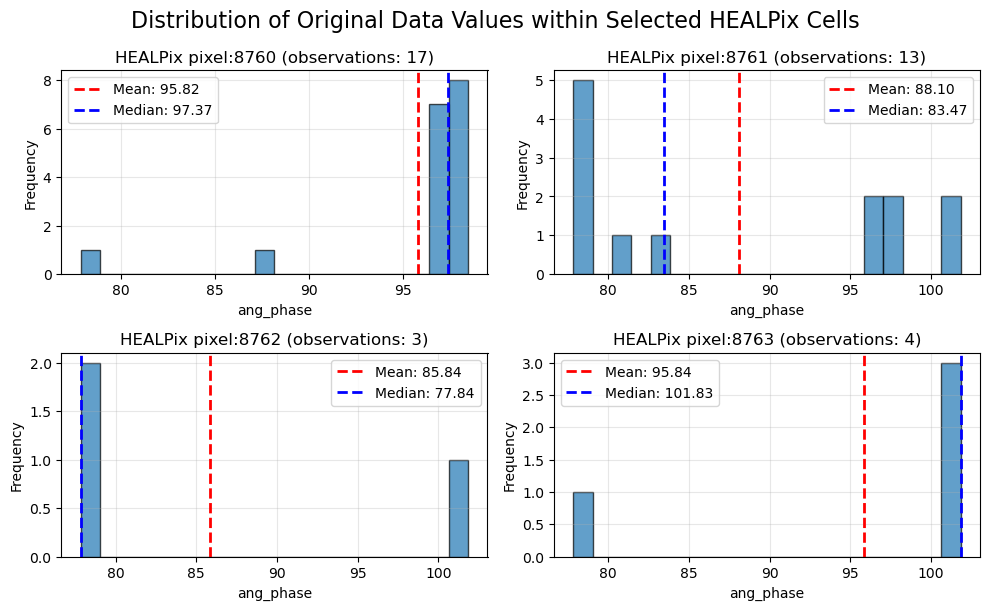

In [ ]:
#| echo: false
selected_cells = sidecar_nside_32_df.query('healpix_id in @pixels_32').drop(columns=['weight']).copy()

grouped = original_df.loc[cell_pixels_nside_32_df][[orignal_plot_config_dict['column']]].reset_index(drop=False).rename(columns={'index': 'source_id'}).merge(selected_cells, on='source_id', how='inner').groupby('healpix_id')

fig, axes = plt.subplots(2, 2, figsize=(orignal_plot_config_dict['figsize'][0], orignal_plot_config_dict['figsize'][0]*orignal_plot_config_dict['aspect']))
axes = axes.flatten()

for idx, (healpix_id, group) in enumerate(grouped):
    ax = axes[idx]
    values = group[orignal_plot_config_dict['column']]
    values.hist(bins=20, ax=ax, edgecolor='k', alpha=0.7)
    
    # Add vertical lines for mean and median
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    
    ax.set_title(f'HEALPix pixel:{int(healpix_id)} (observations: {len(group)})')
    ax.set_xlabel(orignal_plot_config_dict['column'])
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

plt.suptitle('Distribution of Original Data Values within Selected HEALPix Cells', fontsize=16)
plt.tight_layout()

We can visualize each pixel with one of the aggregator function output available in `healpyxel_aggregate` : 

- **`mean`**: Arithmetic mean
- **`median`**: Median (50th percentile)
- **`std`**: Standard deviation
- **`min`**: Minimum value
- **`max`**: Maximum value
- **`mad`**: Median Absolute Deviation (robust to outliers)
- **`robust_std`**: MAD × 1.4826 (equivalent to standard deviation for normal distributions, robust to outliers)

Each function generates one output column per input value column, named `<column>_<agg>` (e.g., `r1050_mean`, `r1050_median`, `r1050_mad`). Robust statistics (`mad`, `robust_std`) are recommended for outlier-prone datasets.

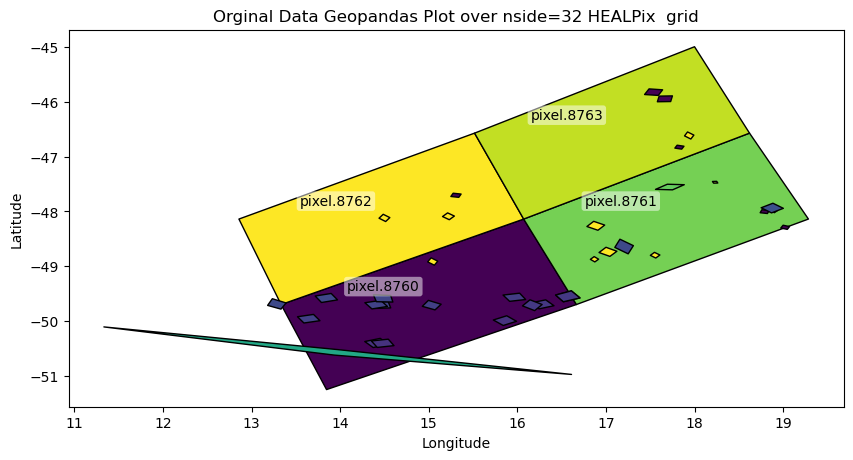

In [ ]:
#| echo: false
ax = aggregated_geo_sparse_nside_32_df.loc[pixels_32].plot(**aggregated_plot_config_dict)

# Annotate each polygon with its healpix_id (index)
for idx, row in aggregated_geo_sparse_nside_32_df.loc[pixels_32].iterrows():
    if row.geometry.is_empty or not row.geometry.is_valid:
        continue
    # Get centroid for label placement
    centroid = row.geometry.centroid
    ax.text(
        centroid.x-.5, centroid.y+.325, f'pixel.{int(idx)}',
        fontsize=10, color='black', ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')
    )

original_df.loc[cell_pixels_nside_32_df].plot(**orignal_plot_config_dict, ax=ax)

ax.set_title('Orginal Data Geopandas Plot over nside=32 HEALPix  grid')
ax.set_xlabel('Longitude');
ax.set_ylabel('Latitude');

## Python API

Minimal end-to-end python API example, each level works on previous one output.

- `initial data` → <!-- raw observations (GeoDataFrame/DataFrame) -->
- `sidecar` : generate data <> healpix grid connections → <!-- maps source_id to healpix_id -->
- `aggregate` → <!-- per-cell statistics on value columns -->
- `attach geometry` → <!-- add HEALPix cell polygons -->
- `accumulate` → <!-- streaming state update (count/mean/m2/tdigest) -->
- `finalize` <!-- final statistics from state -->

minimal code, a more detailed explanation is in [Examples>Visualization](example_visualization_workflow.html) section.

---

```python
from healpyxel import sidecar, aggregate, accumulator, finalize
from healpyxel.geospatial import healpix_to_geodataframe

# Minimal API sanity checks (nbdev-friendly)
assert hasattr(sidecar, "generate")
assert hasattr(aggregate, "by_sidecar")
assert hasattr(accumulator, "update_state")
assert hasattr(finalize, "from_state")
assert callable(healpix_to_geodataframe)

# 1) Sidecar (split)
sidecar_df = sidecar.generate(
    gdf,
    nside=64,
    mode="fuzzy",
    order="nested",
    lon_convention="0_360",
)

# 2) Aggregate (apply)
agg_df = aggregate.by_sidecar(
    original=df,
    sidecar=sidecar_df,
    value_columns=["r750", "r950"],
    aggs=["median", "robust_std"],
    min_count=3,
)

# 2b) Attach geometry to step-2 products (geospatial)
cells_gdf = healpix_to_geodataframe(
    nside=64,
    order="nested",
    lon_convention="0_360",
    pixels=agg_df["healpix_id"].to_numpy(),
    fix_antimeridian=True,
    cache_mode="use",
).reset_index(drop=False)

agg_geo_gdf = cells_gdf.merge(agg_df, on="healpix_id", how="left")

# 3) Accumulator (streaming apply)
state_df = accumulator.update_state(
    batch=df,
    sidecar=sidecar_df,
    value_columns=["r750", "r950"],
    state=None,
)

# 4) Finalize (combine)
final_df = finalize.from_state(
    state=state_df,
    aggs=["mean", "std", "median", "robust_std"],
)
```

## Developed for MESSENGER/MASCS

This package was developed to process spectral observations from the MESSENGER/MASCS instrument studying Mercury's surface. The workflow handles:

- Millions of observations with complex footprint geometries
- Multi-spectral reflectance data (VIS + NIR)
- Streaming data from ongoing missions
- Native resolution mosaics (sub-footprint sampling)

While designed for MASCS, healpyxel is general-purpose and works with any planetary science dataset in GeoParquet format.

### Useful Healpix data for Moon Venus Mercury


In [ ]:
#| echo: false
# Mean planetary radii (km)
R_MERCURY = 2439.7
R_MOON = 1737.4
R_VENUS = 6051.8

nsides = 2 ** np.arange(0, 14, dtype=np.int64)
npix = hp.nside2npix(nsides)
cell_ang_rad = np.sqrt(4 * np.pi / npix)
cell_ang_deg = np.degrees(cell_ang_rad)

df_resolution = pd.DataFrame({
    "nside": nsides,
    "Number of Cells": npix,
    "Cell Angular Size (deg)": cell_ang_deg,
    "Mercury Cell Size (km)": cell_ang_rad * R_MERCURY,
    "Moon Cell Size (km)": cell_ang_rad * R_MOON,
    "Venus Cell Size (km)": cell_ang_rad * R_VENUS,
})

def format_resolution_table(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of the resolution table with int columns formatted with thousand separators and floats rounded to 3 decimals."""
    df_fmt = df.copy()
    int_cols = df_fmt.select_dtypes(include="int64").columns
    float_cols = df_fmt.select_dtypes(include="float64").columns
    for col in int_cols:
        df_fmt[col] = df_fmt[col].map(lambda x: f"{x:,}")
    for col in float_cols:
        df_fmt[col] = df_fmt[col].round(3)
    return df_fmt.set_index("nside")

# Test: Ensure formatting is correct
fmt = format_resolution_table(df_resolution)

display(format_resolution_table(df_resolution))

,Number of Cells,Cell Angular Size (deg),Mercury Cell Size (km),Moon Cell Size (km),Venus Cell Size (km)
nside,,,,,
1,12,58.632,2496.610,1777.928,6192.969
2,48,29.316,1248.305,888.964,3096.484
4,192,14.658,624.153,444.482,1548.242
8,768,7.329,312.076,222.241,774.121
16,"3,072",3.665,156.038,111.120,387.061
32,"12,288",1.832,78.019,55.560,193.530
64,"49,152",0.916,39.010,27.780,96.765
128,"196,608",0.458,19.505,13.890,48.383
256,"786,432",0.229,9.752,6.945,24.191


## License

Apache 2.0